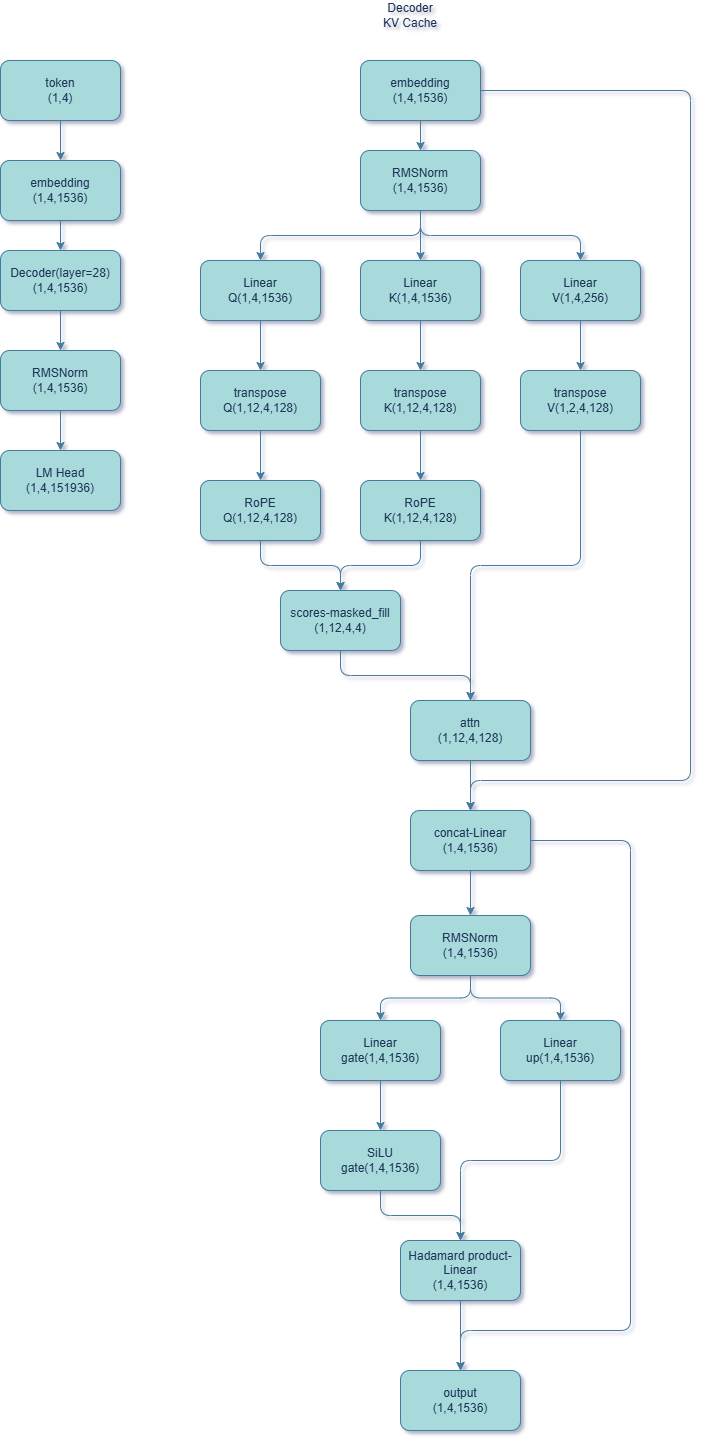

In [2]:
from IPython.display import Image,display
display(Image(filename='Qwen.png'))

In [ ]:
VOCAB = 151936
D = 1536
LAYERS = 28
QH = 12
KVH = 2
HD = 128
FFN = 8960
EPS = 1e-6
THETA = 1e6

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
class RMSNorm(nn.Module):
    def __init__(self,d=D,eps=EPS):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d))
        self.eps = eps
    def forward(self,x):
        rms = x.pow(2).mean(dim=-1,keepdim=True).add(self.eps).sqrt()
        return self.weight * (x / rms)

In [ ]:
def build_rope_cache(max_s,d=HD,theta=THETA):
    inv_freq = 1.0 / theta ** (torch.arange(0,d,2).float() / d)
    t = torch.arange(max_s).float()
    freqs = torch.outer(t,inv_freq)
    emb = torch.cat([freqs,freqs],dim=-1)
    return emb.cos(),emb.sin()
def rotate_half(x):
    x1,x2 = x.chunk(2,dim=-1)
    return torch.cat([-x2,x1],dim=-1)
def apply_rope(x,cos,sin):
    cos = cos[None,None,:,:]
    sin = sin[None,None,:,:]
    return x * cos + rotate_half(x) * sin

In [ ]:
class GQAAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_proj = nn.Linear(D,QH * HD,bias = True)
        self.k_proj = nn.Linear(D,KVH * HD,bias=True)
        self.v_proj = nn.Linear(D,KVH * HD,bias=True)
        self.o_proj = nn.Linear(QH * HD,D,bias=False)
    def forward(self,x,cos,sin,verbose=False):
        B,S,_ = x.shape
        q = self.q_proj(x).view(B,S,QH,HD).transpose(1,2)
        k = self.k_proj(x).view(B,S,KVH,HD).transpose(1,2)
        v = self.v_proj(x).view(B,S,KVH,HD).transpose(1,2)
        q = apply_rope(q,cos,sin)
        k = apply_rope(k,cos,sin)
        k = k.repeat_interleave(QH // KVH,dim=1)
        v = v.repeat_interleave(QH // KVH,dim=1)
        scores = q @ k.transpose(-1,-2) / math.sqrt(HD)
        mask = torch.triu(torch.ones(S,S,dtype=torch.bool),diagonal=1)
        scores = scores.masked_fill(mask,float("-inf"))
        attn = scores.softmax(dim=-1) @ v
        attn = attn.transpose(1,2).reshape(B,S,QH * HD)
        out = self.o_proj(attn)

In [ ]:
class SwiGLUMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.gate_proj = nn.Linear(D,FFN,bias=False)
        self.up_proj = nn.Linear(D,FFN,bias=False)
        self.down_proj = nn.Linear(FFN,D,bias=False)
    def forward(self,x,verbose=False):
        gate = self.gate_proj(x)
        up = self.up_proj(x)
        act = F.silu(gate) * up
        out = self.down_proj(act)
        return out

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = RMSNorm()
        self.attn = GQAAttention()
        self.norm2 = RMSNorm()
        self.mlp = SwiGLUMLP()
    def forward(self,x,cos,sin,verbose=False):
        x = x + self.attn(self.norm1(x),cos,sin,verbose)
        x = x + self.mlp(self.norm2(x),verbose)
        return x

In [ ]:
class QwenForCausalLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB,D)
        self.layers = nn.ModuleList(
            [DecoderLayer() for _ in range(LAYERS)]
        )
        self.norm = RMSNorm()
    def forward(self,ids,verbose_layer=None):
        cos,sin = build_rope_cache(ids.shape[1])
        x = self.embed(ids)
        for i,layer in enumerate(self.layers,1):
            x = layer(x,cos,sin,verbose=(i == verbose_layer))
        x = self.norm(x)
        return x @ self.embed.weight.T

In [ ]:
def forward_cached(attn,x_new,cos,sin,past_k=None,past_v=None):
    Bn,Sn,_ = x_new.shape
    q = attn.q_proj(x_new).view(Bn,Sn,QH,HD).transpose(1,2)
    k = attn.k_proj(x_new).view(Bn,Sn,KVH,HD).transpose(1,2)
    v = attn.v_proj(x_new).view(Bn,Sn,KVH,HD).transpose(1,2)
    q = apply_rope(q,cos[-Sn:],sin[-Sn:])
    k = apply_rope(k,cos[-Sn:],sin[-Sn:])
    if past_k is not None:
        k = torch.cat([past_k,k],dim=2)
        v = torch.cat([past_v,v],dim=2)
    kk = k.repeat_interleave(QH//KVH,dim=1)
    vv = v.repeat_interleave(QH//KVH,dim=1)
    scores = q @ kk.transpose(-1,-2) / math.sqrt(HD)
    a = scores.softmax(-1) @ vv
    a = a.transpose(1,2).reshape(Bn,Sn,QH * HD)
    return attn.o_proj(a),k,v
full = attn(x,cos,sin)
past_k = past_v = None;outs = []
for t in range(S):
    o,past_k,past_v = forward_cached(
        attn,x[:,t:t+1],cos[:t+1],sin[:t+1],past_k,past_v)
    outs.append(o)
cached = torch.cat(outs,dim=1)
assert (full-cached).abs().max() < 1e-5